In [83]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

output_folder = r'output\SMAP_MSL\Proposed\29032026_194435'
# output_folder = r'output\SMAP_MSL\AnomalyTransformer\backup\NonOverlapped\28032026_161753'
file_dir = os.path.join(output_folder, 'test_output.pkl')

# Load test_output.pkl
with open(file_dir, "rb") as f:
    test_output = pickle.load(f)

# Define index range
x = np.arange(len(test_output["A_True_Global"]))

# Identify true and predicted anomalies
true_anomalies = test_output.get("A_True_Global", np.zeros_like(x))
pred_anomalies = test_output.get("A_Pred_Global_bf", np.zeros_like(x))
anomalies = np.where(true_anomalies == 1)[0]
pred_anomalies_idx = np.where(pred_anomalies == 1)[0]

Predicted Anomalies index : 
 [1634 1635 1637 1638 1639 1641 1642 1644 1815 1816 1817 1818 1819 1820
 1821 1822 1823 1824 1825 1826 1827 1828 1829 1830 1831 1832 1833 1834
 1835 1836 1837 1838 1839 1840 1841 1842 1843 1844 1845 1846 1847 1848
 1849 1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862
 1863 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876
 1877 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890
 1891 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904
 1905 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918
 1919 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932
 1933 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946
 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960
 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974
 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988
 1989]


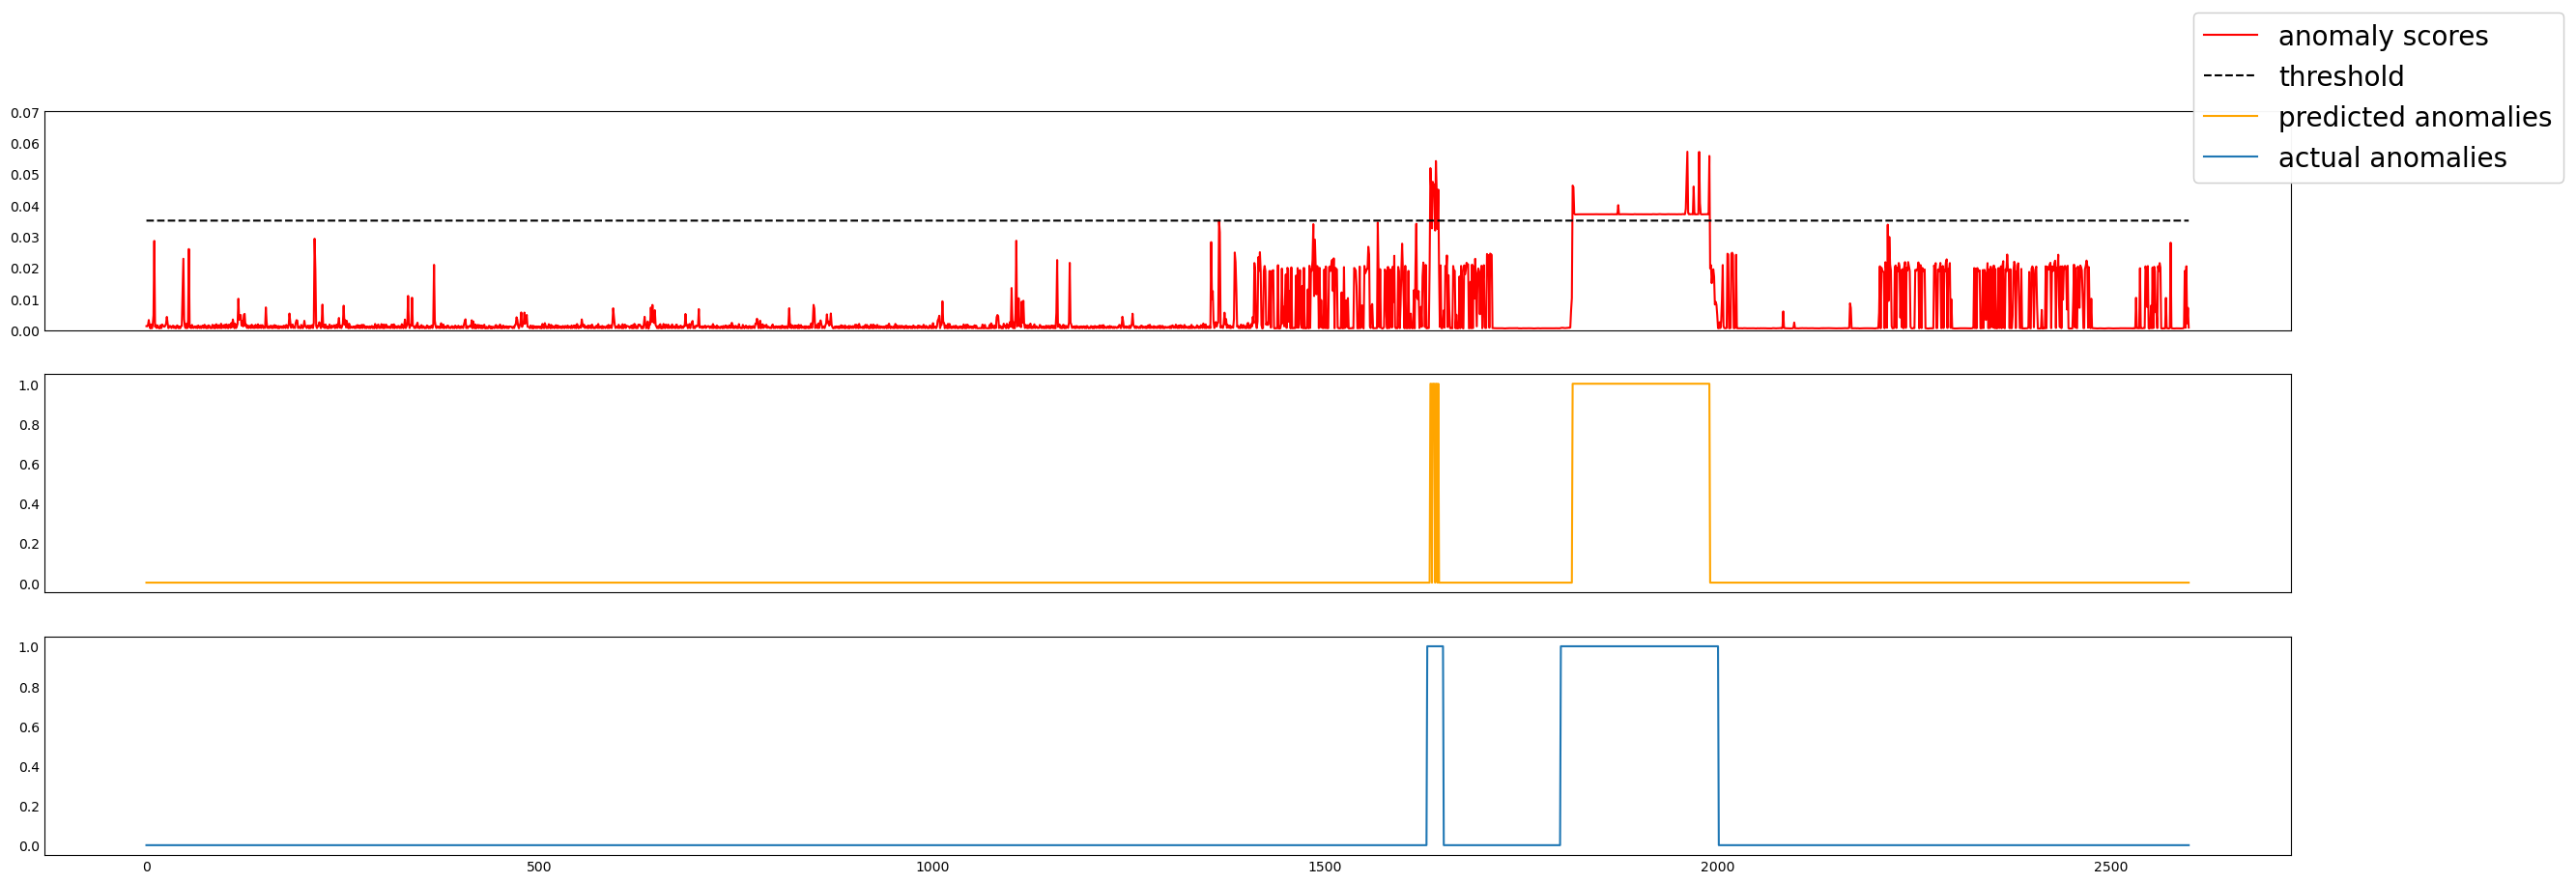

In [84]:
data_copy = test_output.copy()

print(f"Predicted Anomalies index : \n {pred_anomalies_idx}")
fig, axs = plt.subplots(3, figsize=(30, 10), sharex=True)

axs[0].plot(data_copy["A_Score_Global"], c="r", label="anomaly scores")
axs[0].plot(data_copy["Thresh_Global_bf"], linestyle="dashed", c="black", label="threshold")
axs[1].plot(data_copy["A_Pred_Global_bf"], label="predicted anomalies", c="orange")
axs[2].plot(data_copy["A_True_Global"], label="actual anomalies")

axs[0].set_ylim([0, 2 * np.mean(data_copy["Thresh_Global_bf"].values)])
# axs[0].set_ylim([0 , 0.02])
fig.legend(prop={"size": 20})
# plt.show()


# Y축 범위 설정
# axs[0].set_ylim([0, 3 * np.mean(data_copy["Thresh_Global_bf"].values)])

# ---------------------------------------------------------
# [수정된 부분] 모든 서브플롯(axs)에 대해 눈금 선 및 격자 제거 설정
# ---------------------------------------------------------
for ax in axs:
    # 1. 배경의 수평/수직 격자(Grid) 끄기
    ax.grid(False) 
    
    # 2. 축 위의 눈금 표시(작은 작대기) 길이 0으로 설정 (안 보이게 함)
    # axis='both': x, y축 모두 적용
    # which='both': 주 눈금(major)과 보조 눈금(minor) 모두 적용
    ax.tick_params(axis='both', which='both', length=0)

fig.legend(prop={"size": 20})
plt.show()

In [ ]:
# 데이터 복사 (test_output은 기존에 정의되어 있다고 가정)
data_copy = test_output.copy()

print(f"Predicted Anomalies index : \n {pred_anomalies_idx}")

# 3개의 서브플롯 생성 (x축 공유)
fig, axs = plt.subplots(3, figsize=(30, 10), sharex=True)

# 1. 데이터 플로팅
axs[0].plot(data_copy["A_Score_Global"], c="r", label="anomaly scores")
axs[0].plot(data_copy["Thresh_Global_bf"], linestyle="dashed", c="black", label="threshold")
axs[1].plot(data_copy["A_Pred_Global_bf"], label="predicted anomalies", c="orange")
axs[2].plot(data_copy["A_True_Global"], label="actual anomalies")

# 2. Y축 범위 설정
# axs[0].set_ylim([0, 5 * np.mean(data_copy["Thresh_Global_bf"].values)])
axs[0].set_ylim([0 , 4])

# ---------------------------------------------------------
# 3. X축 특정 범위 지정 (줌인 효과)
# 원하는 시작 인덱스와 끝 인덱스를 여기에 입력하세요.
# sharex=True 옵션 덕분에 axs[0]만 설정해도 3개 그래프 모두에 적용됩니다.
start_idx = 18000
end_idx = 22000
axs[0].set_xlim([start_idx, end_idx])
# ---------------------------------------------------------

# 4. [수정된 부분] 격자 및 눈금선 제거
for ax in axs:
    # 배경의 수평/수직 격자(Grid) 끄기
    ax.grid(False) 
    
    # 축 위의 눈금 표시(작은 작대기) 길이 0으로 설정 (안 보이게 함)
    ax.tick_params(axis='both', which='both', length=0)

# 5. 범례 및 그래프 출력
fig.legend(prop={"size": 20})
plt.show()

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# [Helper Function] 연속된 구간 찾기 (기존 동일)
def get_continuous_ranges(indices):
    if len(indices) == 0: return []
    diffs = np.diff(indices)
    breaks = np.where(diffs > 1)[0] + 1
    groups = np.split(indices, breaks)
    ranges = []
    for group in groups:
        if len(group) > 0:
            ranges.append((group[0], group[-1]))
    return ranges

# 1. 라벨 데이터 추출
if 'A_True_Global' in test_output.columns:
    labels = test_output['A_True_Global']
else:
    labels = None

# 2. 데이터 컬럼 필터링
data_copy = test_output.drop(columns=['A_Score_Global', 'Thresh_Global_bf'], errors='ignore')
cols = [c for c in data_copy.columns if not (c.startswith('Thresh_') or c.startswith('A_Pred_'))]

if 'A_True_Global' in cols:
    cols.remove('A_True_Global')
    cols.append('A_True_Global')

data_copy = data_copy[cols]

if labels is not None:
    labels = labels.loc[data_copy.index]

num_cols = data_copy.shape[1]

# ---------------------------------------------------------
# [New] Y축 범위 동기화 로직 (Y-Limit Synchronization)
# ---------------------------------------------------------
# 변수 ID별로 Min/Max를 저장할 딕셔너리
# 예: { '0': (-1.5, 2.0), '1': (0, 10), ... }
ylim_map = {}

for col in data_copy.columns:
    # 컬럼 이름에서 숫자 ID 추출 (예: 'True_0' -> '0', 'Recons_12' -> '12')
    if '_' in col and col.split('_')[-1].isdigit():
        var_id = col.split('_')[-1]
        
        # 현재 컬럼의 min, max 계산
        col_min = data_copy[col].min()
        col_max = data_copy[col].max()
        
        if var_id not in ylim_map:
            ylim_map[var_id] = [col_min, col_max]
        else:
            # 이미 저장된 값과 비교하여 범위를 확장 (더 작은 min, 더 큰 max)
            ylim_map[var_id][0] = min(ylim_map[var_id][0], col_min)
            ylim_map[var_id][1] = max(ylim_map[var_id][1], col_max)

# ---------------------------------------------------------
# 3. 시각화 (최적화 + Y축 동기화 적용)
# ---------------------------------------------------------
print("Plotting start... (Optimized with Synced Y-Axis)")

fig, axes = plt.subplots(nrows=num_cols, ncols=1, figsize=(20, num_cols * 1.5), sharex=True)
fig.tight_layout(pad=1.0)

# 이상치 구간 정보 미리 계산
anomaly_ranges = []
single_points = [] # 단일 점 리스트 미리 선언
if labels is not None:
    anomaly_indices = labels[labels == 1].index.values
    anomaly_ranges = get_continuous_ranges(anomaly_indices)
    
    # 미리 단일 점/연속 구간 분리 (루프 밖에서 한 번만)
    temp_singles = []
    temp_ranges = []
    for start, end in anomaly_ranges:
        if start == end:
            temp_singles.append(start)
        else:
            temp_ranges.append((start, end))
    single_points = temp_singles
    anomaly_ranges = temp_ranges # 덮어쓰기

for i, col in enumerate(data_copy.columns):
    ax = axes[i] if num_cols > 1 else axes
    
    # 색상 설정
    if 'A_Score' in col: color = 'red'
    elif 'A_True_Global' in col: color = 'black'
    else: color = 'gray'
        
    # [최적화 1] rasterized=True
    ax.plot(data_copy.index, data_copy[col], color=color, linewidth=1, zorder=2, rasterized=True)
    
    # [New] 동기화된 Y축 범위 적용
    # 현재 컬럼의 ID가 ylim_map에 있다면 공통 범위 적용
    if '_' in col and col.split('_')[-1].isdigit():
        var_id = col.split('_')[-1]
        if var_id in ylim_map:
            y_min, y_max = ylim_map[var_id]
            
            # 여백(Padding) 10% 추가
            padding = (y_max - y_min) * 0.1 if (y_max - y_min) > 0 else 0.1
            ax.set_ylim(y_min - padding, y_max + padding)

    # [최적화 2] 연속 구간 병합 그리기
    if len(anomaly_ranges) > 0:
        for start, end in anomaly_ranges:
             # axvspan: 화면 전체 높이를 칠하므로 y축 범위와 무관하게 잘 동작함
            ax.axvspan(start, end, color='red', alpha=0.3, zorder=1, rasterized=True)
            
    # [최적화 3] 단일 점 이상치 그리기
    if len(single_points) > 0:
        ax.vlines(x=single_points, 
                  ymin=0, ymax=1, 
                  colors='red', 
                  transform=ax.get_xaxis_transform(), # y축 범위 무시하고 꽉 채움
                  alpha=0.5,
                  linewidth=2, 
                  zorder=1,
                  rasterized=True)

    ax.set_title(col, fontsize=10, pad=3, loc='left', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

plt.xlabel("Index")

print("Rendering...")
plt.show()
print("Done.")

: 

: 